# 激光雷达直方图仿真 (LiDAR Histogram Simulation)

从**激光器发光** → **TX 准直** → **传播/大气** → **目标漫反射(多回波)** → **RX 收集(焦距/口径/阵列)** → **SPAD 探测** → **TCSPC 直方图**。

**本仿真的约定**
- 目标为**扩展面目标**，功率按 **1/D²** 衰减；支持**多回波**。
- 空间光斑用**椭圆高斯**建模（σ_x ≠ σ_y）。
- 时域脉冲用**双指数**建模（P_peak=235 W，全宽≈4.6 ns，单脉冲能量≈800 nJ，形状匹配示波器）。
- RX 纳入 **f_RX / D_RX**，并加入**方形 SPAD 阵列**几何（像元间距、填充因子、iFOV、被照像元数、累加范围）。
- SPAD **不考虑 dead time**，只考虑 **PDE**（+ 可选环境光/暗计数/IRF 抖动）。

> ⚠️ **运行方式**：请用 **Kernel → Restart & Run All**（从上到下按顺序执行）。
> 若只单独运行模块 6/7 会报 `NameError: link_factor`，因为它定义在模块 5 的 cell 里 —— 不是 bug，是漏跑了上面的 cell。

**暂不考虑**（后续再加）：1 零距离串扰峰、7 TDC 量化/非线性、9 内反射、10 入射角cos/非朗伯、
13 大气后向散射、14 温漂、15 符合探测、16 饱和恢复。

## 模块 0 — 参数与常数

所有可调参数集中在嵌套字典 `PARAMS`，按子系统分组。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# ---- 中文字体 (Windows: 微软雅黑/黑体) ----
for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [_f]
        break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

# ---- 物理常数 ----
C_LIGHT = 2.99792458e8      # 光速 [m/s]
H_PLANCK = 6.62607015e-34   # 普朗克常数 [J·s]

# D 相关 plot 的统一距离范围 [m]
D_PLOT_MAX = 300.0

PARAMS = {
    # ---------- 激光源 ----------
    "laser": {
        "wavelength": 905e-9,   # 波长 [m]
        # 幅度定义: "peak"=用 P_peak 定幅(默认) / "energy"=用 E_pulse 定幅
        "amp_mode": "peak",
        "P_peak": 235.0,        # 峰值光功率 [W] (示波器实测)
        "E_pulse": 800e-9,      # 目标单脉冲能量 [J] (amp_mode="energy" 时生效)
        # 双指数时域形状: p(t) ∝ exp(-t/tau_f) - exp(-t/tau_r), t>=0, tau_f>tau_r
        # (0.7, 1.9) ns → 全宽(≈25%峰值)≈4.6 ns, τ_eff=E/P=3.4 ns → 235W×3.4ns≈800 nJ, 三者自洽
        "tau_r": 0.7e-9,        # 上升时间常数 [s]
        "tau_f": 1.9e-9,        # 下降时间常数 [s]
        # 空间(椭圆高斯, 1/e^2 全宽; X 为慢轴更长 → 图一 X 向拉长)
        "x_L": 200e-6,          # 发光面 X 等效尺寸 [m]
        "y_L": 100e-6,          # 发光面 Y 等效尺寸 [m]
    },

    # ---------- TX 发射光学 ----------
    "tx": {
        "f_TX": 20e-3,          # 发射物镜焦距 [m]
        "D_TX": 10e-3,          # 发射通光口径(准直光束直径) [m] -> w0 = D_TX/2
        "eta_coupling": 0.90,   # 发射角度耦合效率
        "T_TX": 0.90,           # 发射透过率
    },

    # ---------- 信道 / 大气 ----------
    "channel": {
        "alpha": 0.2e-3,        # 大气消光系数 @905nm [1/m] (0.2/km≈晴朗)
    },

    # ---------- 目标 (多回波) ----------
    "target": {
        "echoes": [
            {"D": 30.0, "rho": 0.30, "frac": 0.30, "tilt_deg": 0.0,  "name": "近处物体(边缘拦截)"},
            {"D": 50.0, "rho": 0.20, "frac": 0.60, "tilt_deg": 30.0, "name": "主目标(倾斜墙面)"},
            {"D": 62.0, "rho": 0.10, "frac": 0.10, "tilt_deg": 0.0,  "name": "远处背景"},
        ],
    },

    # ---------- RX 接收光学 ----------
    "rx": {
        "f_RX": 20e-3,          # 接收物镜焦距 [m]  → 决定成像放大率/iFOV
        "D_RX": 25e-3,          # 接收口径 [m]      → 决定收集立体角 A_RX
        "eta_RX": 0.80,         # 接收耦合效率
        "T_RX": 0.90,           # 接收透过率
        "T_filter": 0.70,       # 窄带滤光片透过率
    },

    # ---------- SPAD 器件 ----------
    "spad": {
        "PDE": 0.10,            # 光子探测效率
        "DCR": 1.0e3,           # 单像元暗计数率 [cps]
        "jitter_sigma": 150e-12,# IRF 高斯 sigma [s] (SPAD 雪崩抖动 + TDC)
    },

    # ---------- 方形 SPAD 阵列 ----------
    "spad_array": {
        "pitch": 30e-6,         # 方形像元间距 [m]
        "Nx": 16, "Ny": 16,     # 阵列规模
        "fill_factor": 0.70,    # 有效面积填充因子(像元间猝灭电路死区; 微透镜可提升)
        "sum_pixels": "illuminated",  # 累加范围: "illuminated"仅被照像元 / "all"整个阵列
    },

    # ---------- 环境光 ----------
    "ambient": {
        "rate": 20e3,           # 单像元环境光(经滤光片后)计数率 [cps]; 设0则关闭
    },

    # ---------- 直方图 / TCSPC ----------
    "hist": {
        "t_max": 500e-9,        # 时间窗 [s] (~75 m)
        "bin_width": 1e-9,      # TDC bin 宽 [s]  → 1 ns (对应 15 cm 距离 bin)
        "dt_fine": 25e-12,      # 卷积用精细网格 [s] (远小于 IRF, 保证卷积准确)
        "N_shots": 1000,        # 累加脉冲数(帧数)
        "seed": 0,
    },
}

# 派生常数
E_PHOTON = H_PLANCK * C_LIGHT / PARAMS["laser"]["wavelength"]
print(f"单光子能量 E_photon = {E_PHOTON:.3e} J  ({E_PHOTON/1.602e-19:.3f} eV)")
print(f"1 ns bin -> 距离分辨 {C_LIGHT*1e-9/2*100:.1f} cm;  时间窗 {PARAMS['hist']['t_max']*1e9:.0f} ns -> "
      f"最远 {PARAMS['hist']['t_max']*C_LIGHT/2:.0f} m")

单光子能量 E_photon = 2.195e-19 J  (1.370 eV)
1 ns bin -> 距离分辨 15.0 cm;  时间窗 500 ns -> 最远 75 m


## 模块 1 — 激光源

### 空间
椭圆高斯 `S(x,y)=exp(-2x²/w_x²-2y²/w_y²)`，`w=尺寸/2`。X 为慢轴(多发光区)更长 → 远场沿 X 拉长(图一)。

### 时间（双指数）
`p(t)=exp(-t/τ_f)-exp(-t/τ_r)`，`t≥0`。**你自己的 rise/fall/FWHM/peak 模型可直接替换 `pulse_temporal`。**

### 幅度、能量、脉宽的锁定关系（对应你的问题 1 & 3）
三个量由 `E=∫P dt` 相互锁定，只有 **2 个自由度**，不能独立乱填：
- 目标：P_peak=**235 W**、全宽≈**4.6 ns**、E≈**800 nJ**。
- 等效矩形宽度 `τ_eff = E/P_peak = 800nJ/235W ≈ 3.40 ns`（对标示波器 面积/峰值 = 236.8pV·s/51.13mV ≈ 4.63 ns 的量纲，
  注意示波器那个是电压面积/电压峰值，与光功率 τ_eff 概念一致但数值取决于形状）。
- 选双指数 (τ_r,τ_f)=(0.7,1.9) ns 时：**τ_eff=3.4 ns → 235W×3.4ns≈800 nJ 自洽**，FWHM≈3 ns，
  而"全宽"(≈25% 峰值处)≈4.6 ns，与你说的"全宽 4.6 ns（非半高全宽）"吻合。
- `amp_mode`: `"peak"` 锁 235 W（能量由形状算出）；`"energy"` 锁 800 nJ（峰值反推）。默认 `"peak"`。
- **激光器的"指定"就是**：给形状(τ_r,τ_f) + 二选一的幅度基准(P_peak 或 E_pulse)，第三个量自动得出。

[amp_mode = peak]
峰值功率 P_peak     = 235.0 W
单脉冲能量 E        = 799.4 nJ   (目标 ~800 nJ)
等效宽度 τ_eff=E/P  = 3.40 ns
FWHM(半高全宽)     = 2.94 ns
全宽(~25% 峰值)     = 4.47 ns   (目标 4.6 ns)
全宽(1% 峰值)       = 10.73 ns
上升(10-90%)       = 0.62 ns   下降(90-10%) = 4.61 ns


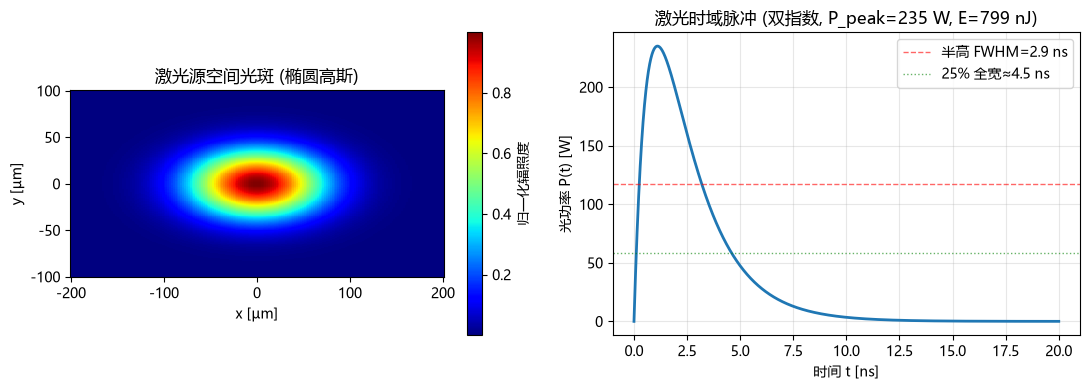

In [2]:
def spot_spatial(x, y, p=PARAMS):
    """空间椭圆高斯(峰值归一)."""
    wx = p["laser"]["x_L"] / 2.0
    wy = p["laser"]["y_L"] / 2.0
    return np.exp(-2.0 * (x**2) / wx**2 - 2.0 * (y**2) / wy**2)


def _pulse_norm(p=PARAMS):
    """双指数解析归一: 返回 幅度A[W], 峰值形状值s_peak, 峰值时刻t_peak, 形状积分area_shape."""
    tr, tf = p["laser"]["tau_r"], p["laser"]["tau_f"]
    t_peak = np.log(tf / tr) / (1.0 / tr - 1.0 / tf)
    s_peak = np.exp(-t_peak / tf) - np.exp(-t_peak / tr)
    area_shape = tf - tr                          # ∫0∞ (e^{-t/tf}-e^{-t/tr}) dt
    if p["laser"]["amp_mode"] == "energy":
        A = p["laser"]["E_pulse"] * s_peak / area_shape
    else:
        A = p["laser"]["P_peak"]
    return A, s_peak, t_peak, area_shape


def pulse_temporal(t, p=PARAMS):
    """双指数时域脉冲 [W], t<0 处为0. 峰值=A."""
    tr, tf = p["laser"]["tau_r"], p["laser"]["tau_f"]
    A, s_peak, _, _ = _pulse_norm(p)
    tpos = np.clip(t, 0.0, None)                  # 避免 t<0 时 exp(-t/tr) 溢出
    shape = np.where(t >= 0, np.exp(-tpos / tf) - np.exp(-tpos / tr), 0.0)
    shape = np.clip(shape, 0.0, None)
    return A * shape / s_peak


def pulse_metrics(p=PARAMS):
    """数值统计脉冲特征."""
    t = np.linspace(0, 40e-9, 400001)
    P = pulse_temporal(t, p)
    pk = P.max()
    fwhm = (lambda a: a[-1] - a[0])(t[P >= 0.5 * pk])
    full_25 = (lambda a: a[-1] - a[0])(t[P >= 0.25 * pk])   # ~25%峰值处的"全宽"
    full_1 = (lambda a: a[-1] - a[0])(t[P >= 0.01 * pk])
    i_pk = np.argmax(P)
    rise = np.interp(0.9 * pk, P[:i_pk + 1], t[:i_pk + 1]) - np.interp(0.1 * pk, P[:i_pk + 1], t[:i_pk + 1])
    td, Pd = t[i_pk:], P[i_pk:]
    fall = np.interp(0.1 * pk, Pd[::-1], td[::-1]) - np.interp(0.9 * pk, Pd[::-1], td[::-1])
    energy = np.trapezoid(P, t)
    return {"FWHM": fwhm, "full_25": full_25, "full_1pct": full_1, "rise_10_90": rise,
            "fall_90_10": fall, "energy": energy, "peak": pk, "tau_eff": energy / pk}

_m = pulse_metrics()
print(f"[amp_mode = {PARAMS['laser']['amp_mode']}]")
print(f"峰值功率 P_peak     = {_m['peak']:.1f} W")
print(f"单脉冲能量 E        = {_m['energy']*1e9:.1f} nJ   (目标 ~800 nJ)")
print(f"等效宽度 τ_eff=E/P  = {_m['tau_eff']*1e9:.2f} ns")
print(f"FWHM(半高全宽)     = {_m['FWHM']*1e9:.2f} ns")
print(f"全宽(~25% 峰值)     = {_m['full_25']*1e9:.2f} ns   (目标 4.6 ns)")
print(f"全宽(1% 峰值)       = {_m['full_1pct']*1e9:.2f} ns")
print(f"上升(10-90%)       = {_m['rise_10_90']*1e9:.2f} ns   下降(90-10%) = {_m['fall_90_10']*1e9:.2f} ns")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
gx = np.linspace(-PARAMS["laser"]["x_L"], PARAMS["laser"]["x_L"], 200)
gy = np.linspace(-PARAMS["laser"]["y_L"], PARAMS["laser"]["y_L"], 200)
GX, GY = np.meshgrid(gx, gy)
im = ax[0].pcolormesh(GX * 1e6, GY * 1e6, spot_spatial(GX, GY), shading="auto", cmap="jet")
ax[0].set_title("激光源空间光斑 (椭圆高斯)")
ax[0].set_xlabel("x [µm]"); ax[0].set_ylabel("y [µm]"); ax[0].set_aspect("equal")
plt.colorbar(im, ax=ax[0], label="归一化辐照度")
tt = np.linspace(0, 20e-9, 3000)
ax[1].plot(tt * 1e9, pulse_temporal(tt), lw=2)
ax[1].axhline(_m["peak"]/2, color="r", ls="--", lw=1, alpha=0.6, label=f"半高 FWHM={_m['FWHM']*1e9:.1f} ns")
ax[1].axhline(_m["peak"]*0.25, color="g", ls=":", lw=1, alpha=0.6, label=f"25% 全宽≈{_m['full_25']*1e9:.1f} ns")
ax[1].set_title(f"激光时域脉冲 (双指数, P_peak={_m['peak']:.0f} W, E={_m['energy']*1e9:.0f} nJ)")
ax[1].set_xlabel("时间 t [ns]"); ax[1].set_ylabel("光功率 P(t) [W]")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 模块 2 — TX 发射光学

半发散角取几何项与衍射项的平方和：
- 几何/étendue：`θ_x=x_L/(2 f_TX)`，`θ_y=y_L/(2 f_TX)`（x_L>y_L ⇒ X 更发散，与图一致）。
- 衍射极限：`θ_diff≈λ/(π w0)`，`w0=D_TX/2`。

瑞利距离 `z_R≈w0/θ`。出光效率 `η_TX=η_coupling·T_TX`。

In [3]:
def tx_derived(p=PARAMS):
    x_L, y_L = p["laser"]["x_L"], p["laser"]["y_L"]
    f_TX = p["tx"]["f_TX"]; lam = p["laser"]["wavelength"]; w0 = p["tx"]["D_TX"] / 2.0
    tgx, tgy = x_L / (2 * f_TX), y_L / (2 * f_TX)
    tdf = lam / (np.pi * w0)
    tx_, ty_ = np.hypot(tgx, tdf), np.hypot(tgy, tdf)
    return {"theta_x": tx_, "theta_y": ty_, "theta_geom_x": tgx, "theta_geom_y": tgy,
            "theta_diff": tdf, "zR_x": w0 / tx_, "zR_y": w0 / ty_, "w0": w0,
            "eta_TX": p["tx"]["eta_coupling"] * p["tx"]["T_TX"]}

_tx = tx_derived()
print(f"半发散角  θ_x = {_tx['theta_x']*1e3:.3f} mrad,  θ_y = {_tx['theta_y']*1e3:.3f} mrad")
print(f"  (几何 {_tx['theta_geom_x']*1e3:.3f}/{_tx['theta_geom_y']*1e3:.3f} mrad, 衍射下限 {_tx['theta_diff']*1e3:.4f} mrad)")
print(f"瑞利距离  z_R,x = {_tx['zR_x']:.3f} m,  z_R,y = {_tx['zR_y']:.3f} m")
print(f"出光效率  η_TX = {_tx['eta_TX']:.3f}")

半发散角  θ_x = 5.000 mrad,  θ_y = 2.501 mrad
  (几何 5.000/2.500 mrad, 衍射下限 0.0576 mrad)
瑞利距离  z_R,x = 1.000 m,  z_R,y = 1.999 m
出光效率  η_TX = 0.810


## 模块 3 — 信道（大气 + 光斑扩展 + 飞行时间）

- 单程大气 `T_atm(D)=exp(-αD)`（**往返 exp(-2αD)**）。
- 光斑全宽 `x_D≈(x_L/f_TX)·D`，`y_D≈(y_L/f_TX)·D`（近场用完整高斯束公式）。
- 飞行时间 `t_ToF=2D/c`。
- **所有 D 相关 plot 扫到 300 m。**

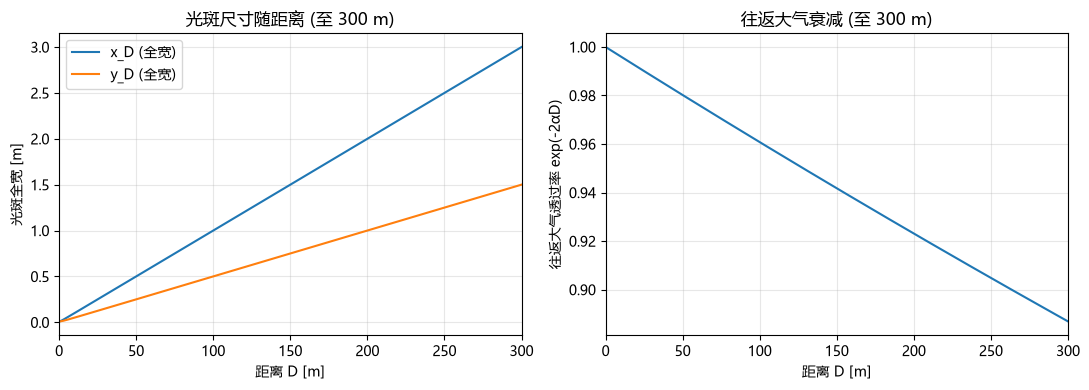

D=   30 m:  光斑   30.0 ×   15.0 cm,  t_ToF=  200.1 ns
D=   50 m:  光斑   50.0 ×   25.0 cm,  t_ToF=  333.6 ns
D=   62 m:  光斑   62.0 ×   31.0 cm,  t_ToF=  413.6 ns


In [4]:
def atm_transmission(D, p=PARAMS):
    return np.exp(-p["channel"]["alpha"] * D)

def beam_spot_size(D, p=PARAMS):
    tx = tx_derived(p); w0 = tx["w0"]
    return (2 * w0 * np.sqrt(1 + (D / tx["zR_x"])**2),
            2 * w0 * np.sqrt(1 + (D / tx["zR_y"])**2))

def beam_area(D, p=PARAMS):
    x_D, y_D = beam_spot_size(D, p)
    return np.pi / 4.0 * x_D * y_D

def time_of_flight(D):
    return 2.0 * D / C_LIGHT

Ds = np.linspace(0.1, D_PLOT_MAX, 600)
xD = np.array([beam_spot_size(d)[0] for d in Ds])
yD = np.array([beam_spot_size(d)[1] for d in Ds])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(Ds, xD, label="x_D (全宽)"); ax[0].plot(Ds, yD, label="y_D (全宽)")
ax[0].set_xlabel("距离 D [m]"); ax[0].set_ylabel("光斑全宽 [m]")
ax[0].set_title("光斑尺寸随距离 (至 300 m)"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_xlim(0, D_PLOT_MAX)
ax[1].plot(Ds, atm_transmission(Ds)**2)
ax[1].set_xlabel("距离 D [m]"); ax[1].set_ylabel("往返大气透过率 exp(-2αD)")
ax[1].set_title("往返大气衰减 (至 300 m)"); ax[1].grid(alpha=0.3); ax[1].set_xlim(0, D_PLOT_MAX)
plt.tight_layout(); plt.show()
for e in PARAMS["target"]["echoes"]:
    d = e["D"]; xd, yd = beam_spot_size(d)
    print(f"D={d:>5.0f} m:  光斑 {xd*100:6.1f} × {yd*100:6.1f} cm,  t_ToF={time_of_flight(d)*1e9:7.1f} ns")

## 模块 4 — 目标（反射率 + 朗伯漫反射 + 多回波）

朗伯体：法向辐射强度 `I0=ρ·P_hit/π`（**ρ/π = 朗伯 BRDF**）。
多回波：光斑横跨多个距离，第 k 面拦截比例 `frac_k`、距离 `D_k`、反射率 `ρ_k` → 延迟脉冲副本叠加。
倾角展宽：`Δt=2 w tanφ/c`。

In [5]:
def lambertian_brdf(rho):
    return rho / np.pi

def echo_range_broadening_sigma(D, tilt_deg, p=PARAMS):
    x_D, y_D = beam_spot_size(D, p)
    w = 0.5 * np.hypot(x_D, y_D) / np.sqrt(2)
    dz = w * np.tan(np.deg2rad(tilt_deg))
    return (2.0 * dz / C_LIGHT) / 2.0

def check_frac_sum(p=PARAMS):
    s = sum(e["frac"] for e in p["target"]["echoes"])
    tag = "OK" if s <= 1.0 + 1e-9 else "⚠ >1 不物理"
    print(f"各回波拦截比例之和 = {s:.2f}  [{tag}];  余下 {max(0,1-s):.2f} 穿过未拦截")
    return s

check_frac_sum()
for e in PARAMS["target"]["echoes"]:
    sig = echo_range_broadening_sigma(e["D"], e["tilt_deg"])
    print(f"  {e['name']:<16} D={e['D']:>5.0f} m, ρ={e['rho']}, frac={e['frac']}, "
          f"倾角={e['tilt_deg']}° → 展宽σ={sig*1e12:.0f} ps")

各回波拦截比例之和 = 1.00  [OK];  余下 0.00 穿过未拦截
  近处物体(边缘拦截)       D=   30 m, ρ=0.3, frac=0.3, 倾角=0.0° → 展宽σ=0 ps
  主目标(倾斜墙面)        D=   50 m, ρ=0.2, frac=0.6, 倾角=30.0° → 展宽σ=381 ps
  远处背景             D=   62 m, ρ=0.1, frac=0.1, 倾角=0.0° → 展宽σ=0 ps


## 模块 5 — RX 接收光学（焦距/口径 + 方形 SPAD 阵列）

### LiDAR 方程（扩展目标，1/D²）
$$P_{RX,k}(t)=P\!\left(t-\tfrac{2D_k}{c}\right)\cdot \eta_{TX}\cdot frac_k\cdot \frac{\rho_k}{\pi}\cdot \frac{A_{RX}}{D_k^2}\cdot e^{-2\alpha D_k}\cdot \eta_{RX}\cdot T_{RX}\cdot T_{filter}$$
`A_RX=π(D_RX/2)²`，`Ω=A_RX/D²`。

### f_RX 通过成像进入：SPAD 阵列几何
RX 镜把距离 D 的光斑**成像**到探测面，放大率 `m=f_RX/D`：
- **像面光斑** `s=(x_D,y_D)·m`。由于 `x_D∝D` 而 `m∝1/D` → **像面光斑≈发光区的像 `x_L·f_RX/f_TX`，与距离几乎无关**。
- **单像元 iFOV** `=pitch/f_RX`；阵列总 FOV `=N·iFOV`。
- **被照像元数** `n_cov≈(s_x/pitch)(s_y/pitch)`。

### 方形 SPAD 阵列的影响（回答你的问题 2）
1. **填充因子**：方形像元间有猝灭电路/保护环死区 → 有效 `η_geo≈fill_factor`（微透镜可补偿）。
2. **信号被多像元瓜分**：像斑覆盖 `n_cov` 个像元，单像元光子更少 → pile-up 更轻；累加恢复总量。
3. **累加范围决定 SNR**：信号只在被照 `n_cov` 个像元，但**背景每个像元都有**。
   只累加被照像元 → 背景∝`n_cov`；累加整阵列 → 背景∝`Nx·Ny`（噪声 ×`Nx·Ny/n_cov`，SNR 变差）。
4. **视差/像斑走动**：TX-RX 不同轴时像斑随距离在阵列上平移 → 近距点亮不同像元。
5. 像元间**串扰**、**PDE/时延不均匀**、圆像斑与方形网格**重叠**依赖对准。

> 本模块用 `fill_factor` 作 `η_geo`，并按 `sum_pixels` 让背景在 `n_cov` 或 `Nx·Ny` 上累加（体现第 3 点）。

接收孔径 A_RX = 4.909 cm²
像面光斑(@50m) = 200 × 100 µm  (≈发光区的像 200 µm, 与距离几乎无关)
单像元 iFOV = 1.500 mrad,  阵列总 FOV = 24.0 × 24.0 mrad
被照像元数 n_cov ≈ 7×4 = 28 (整阵列 256)
探测效率 η=PDE×填充 = 0.070   累加像元数 n_sum=28 (模式='illuminated')


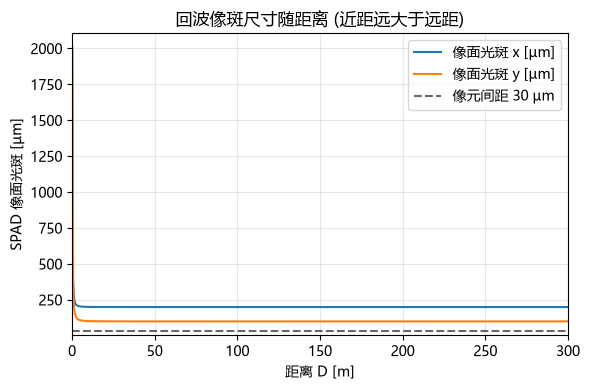

  近处物体(边缘拦截)       link=6.303e-09,  P_RX_peak=1481.1257 nW
  主目标(倾斜墙面)        link=3.001e-09,  P_RX_peak=705.2755 nW
  远处背景             link=1.619e-10,  P_RX_peak=38.0408 nW


In [6]:
def rx_area(p=PARAMS):
    return np.pi * (p["rx"]["D_RX"] / 2.0)**2

def rx_image_spot_size(D, p=PARAMS):
    x_D, y_D = beam_spot_size(D, p)
    m = p["rx"]["f_RX"] / D
    return x_D * m, y_D * m

def array_geometry(D, p=PARAMS):
    sx, sy = rx_image_spot_size(D, p)
    a = p["spad_array"]
    ncx = int(min(a["Nx"], max(1, np.ceil(sx / a["pitch"]))))
    ncy = int(min(a["Ny"], max(1, np.ceil(sy / a["pitch"]))))
    iFOV = a["pitch"] / p["rx"]["f_RX"]
    return {"spot_x": sx, "spot_y": sy, "ncx": ncx, "ncy": ncy, "n_cov": ncx * ncy,
            "iFOV": iFOV, "fov_x": a["Nx"] * iFOV, "fov_y": a["Ny"] * iFOV}

def eta_detection(p=PARAMS):
    """探测效率 = PDE × 填充因子."""
    return p["spad"]["PDE"] * p["spad_array"]["fill_factor"]

def n_sum_pixels(p=PARAMS):
    a = p["spad_array"]
    if a["sum_pixels"] == "all":
        return a["Nx"] * a["Ny"]
    primary = max(p["target"]["echoes"], key=lambda e: e["frac"])
    return array_geometry(primary["D"], p)["n_cov"]

def link_factor(echo, p=PARAMS):
    """单回波链路功率系数(无量纲): P_RX_peak = P_peak × link_factor."""
    tx = tx_derived(p); D = echo["D"]
    Omega = rx_area(p) / D**2
    T_atm2 = atm_transmission(D, p)**2
    eta_rx_total = p["rx"]["eta_RX"] * p["rx"]["T_RX"] * p["rx"]["T_filter"]
    return tx["eta_TX"] * echo["frac"] * lambertian_brdf(echo["rho"]) * Omega * T_atm2 * eta_rx_total

print(f"接收孔径 A_RX = {rx_area()*1e4:.3f} cm²")
_D_demo = PARAMS["target"]["echoes"][1]["D"]      # 用主目标距离做演示
_g = array_geometry(_D_demo)
print(f"像面光斑(@{_D_demo:.0f}m) = {_g['spot_x']*1e6:.0f} × {_g['spot_y']*1e6:.0f} µm  "
      f"(≈发光区的像 {PARAMS['laser']['x_L']*PARAMS['rx']['f_RX']/PARAMS['tx']['f_TX']*1e6:.0f} µm, 与距离几乎无关)")
print(f"单像元 iFOV = {_g['iFOV']*1e3:.3f} mrad,  阵列总 FOV = {_g['fov_x']*1e3:.1f} × {_g['fov_y']*1e3:.1f} mrad")
print(f"被照像元数 n_cov ≈ {_g['ncx']}×{_g['ncy']} = {_g['n_cov']} (整阵列 {PARAMS['spad_array']['Nx']*PARAMS['spad_array']['Ny']})")
print(f"探测效率 η=PDE×填充 = {eta_detection():.3f}   累加像元数 n_sum={n_sum_pixels()} (模式='{PARAMS['spad_array']['sum_pixels']}')")
# 像面光斑随距离 (至 300 m)
sx_arr = np.array([rx_image_spot_size(d)[0] for d in Ds]) * 1e6
sy_arr = np.array([rx_image_spot_size(d)[1] for d in Ds]) * 1e6
plt.figure(figsize=(6, 4))
plt.plot(Ds, sx_arr, label="像面光斑 x [µm]"); plt.plot(Ds, sy_arr, label="像面光斑 y [µm]")
plt.axhline(PARAMS["spad_array"]["pitch"]*1e6, color="k", ls="--", alpha=0.6, label=f"像元间距 {PARAMS['spad_array']['pitch']*1e6:.0f} µm")
plt.xlabel("距离 D [m]"); plt.ylabel("SPAD 像面光斑 [µm]"); plt.xlim(0, D_PLOT_MAX)
plt.title("回波像斑尺寸随距离 (近距远大于远距)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
for e in PARAMS["target"]["echoes"]:
    lf = link_factor(e)
    print(f"  {e['name']:<16} link={lf:.3e},  P_RX_peak={PARAMS['laser']['P_peak']*lf*1e9:.4f} nW")

## 模块 6 — SPAD 探测 + 直方图 (TCSPC)

### 什么是 IRF（回答你的问题）
**IRF = Instrument Response Function（仪器响应函数）**：系统对一个**理想 δ 光脉冲**的时间响应——
"若打进来的是无限窄的一束光，测到的时间展布是什么样"。它打包了**除激光脉冲形状、目标几何之外**的所有定时模糊：
- **SPAD 雪崩定时抖动**（光子吸收→雪崩越阈的时间涨落，几十~几百 ps，常带扩散长尾）；
- **TDC/触发电路抖动与量化**；
- **激光触发-出光抖动**、光电路色散。

这里用**高斯** σ_IRF 近似（更真可加指数尾）。测得峰 = **激光脉冲 ⊛ 目标距离响应 ⊛ IRF**。
IRF 决定测距精度下限与峰的最小宽度。

### 卷积怎么实现（回答你的问题）
**bin=1 ns 远大于 IRF(150 ps)**，直接在 1 ns 网格卷积会把 IRF 抹成一个点、算不准。所以分三步：
1. **精细网格** `dt_fine=25 ps` 上构造每回波探测光子率 `r_det(t)=延迟脉冲×link/E_photon×η`；
2. 与**高斯核**卷积，`σ_tot=√(σ_tilt²+σ_IRF²)`（高斯卷积方差相加；倾角展宽近似为高斯）；核归一化 `Σk·dt=1` 保证光子数守恒；
3. **rebin 到 1 ns**：`λ_i=N_shots·Σ_{fine∈bin_i} r_det·dt_fine`（用 `np.bincount` 按 bin 求和）。

背景(环境+暗计数)按**累加像元数 n_sum** 加常数底；实际计数 `C_i~Poisson(λ_i)`。**不考虑 dead time。**

In [7]:
def gaussian_kernel(sigma, dt, n_sigma=5):
    if sigma <= 0:
        return np.array([1.0 / dt])
    half = max(1, int(np.ceil(n_sigma * sigma / dt)))
    tk = np.arange(-half, half + 1) * dt
    k = np.exp(-0.5 * (tk / sigma)**2)
    return k / (k.sum() * dt)

def build_expected_histogram(p=PARAMS):
    """精细网格卷积 → rebin 到 1 ns bin, 得到每-bin 期望计数 λ_i."""
    dt_bin = p["hist"]["bin_width"]; t_max = p["hist"]["t_max"]
    nbins = int(round(t_max / dt_bin))
    tc = (np.arange(nbins) + 0.5) * dt_bin
    dt_fine = p["hist"]["dt_fine"]
    tf = np.arange(0, t_max, dt_fine)
    bin_idx = np.clip((tf / dt_bin).astype(int), 0, nbins - 1)
    N = p["hist"]["N_shots"]; eta = eta_detection(p); sig_irf = p["spad"]["jitter_sigma"]

    per_echo = []; lam_signal = np.zeros(nbins)
    for e in p["target"]["echoes"]:
        t0 = time_of_flight(e["D"])
        r_det = pulse_temporal(tf - t0, p) * link_factor(e, p) / E_PHOTON * eta
        sig = np.hypot(echo_range_broadening_sigma(e["D"], e["tilt_deg"], p), sig_irf)
        r_det = np.convolve(r_det, gaussian_kernel(sig, dt_fine), mode="same") * dt_fine
        lam_e = N * np.bincount(bin_idx, weights=r_det * dt_fine, minlength=nbins)
        lam_signal += lam_e; per_echo.append(lam_e)

    r_bg = (p["ambient"]["rate"] + p["spad"]["DCR"]) * n_sum_pixels(p)
    lam_bg = np.full(nbins, N * r_bg * dt_bin)
    return {"tc": tc, "dt": dt_bin, "lam_total": lam_signal + lam_bg,
            "lam_signal": lam_signal, "lam_bg": lam_bg, "per_echo": per_echo}

def sample_histogram(expected, seed=0):
    return np.random.default_rng(seed).poisson(expected["lam_total"])

## 模块 7 — 全链路装配 + 可视化

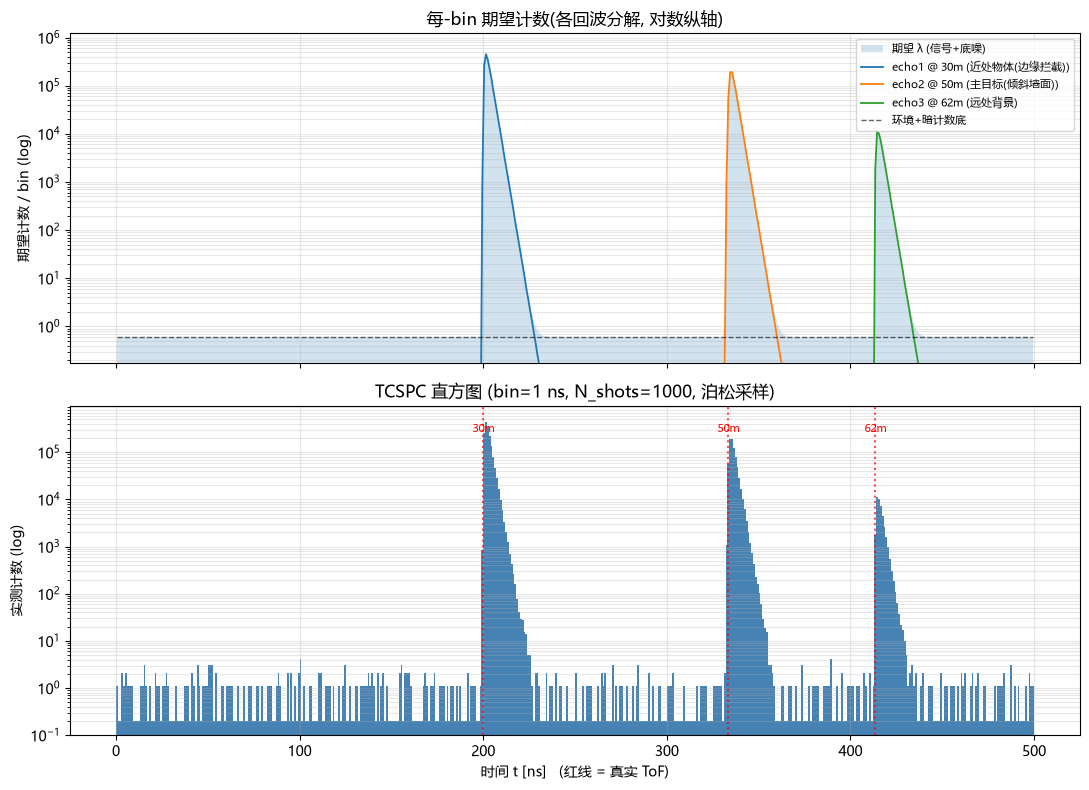

链路预算  (amp_mode=peak, P_peak=235 W, E=799 nJ)
近处物体(边缘拦截)       D=   30m | 入射  22955.31 ph/pulse | 探测 1606.871 ph/pulse | 累加 1606871 ph
主目标(倾斜墙面)        D=   50m | 入射  10930.75 ph/pulse | 探测  765.153 ph/pulse | 累加 765153 ph
远处背景             D=   62m | 入射    589.58 ph/pulse | 探测   41.270 ph/pulse | 累加 41270 ph

峰值 bin 计数 ≈ 450838  |  信号总光子 ≈ 2413339  |  底噪/bin ≈ 0.588 (n_sum=28 像元)
提示: spad_array['sum_pixels'] 改 'all' → 底噪 ×9.1, SNR 变差。


In [8]:
exp = build_expected_histogram(PARAMS)
counts = sample_histogram(exp, seed=PARAMS["hist"]["seed"])
tc_ns = exp["tc"] * 1e9

fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
# (上) 期望, 对数 y (弱回波/底噪可见)
ax[0].fill_between(tc_ns, np.maximum(exp["lam_total"], 1e-3), 1e-3, step="mid", alpha=0.20, label="期望 λ (信号+底噪)")
for i, (e, le) in enumerate(zip(PARAMS["target"]["echoes"], exp["per_echo"])):
    ax[0].plot(tc_ns, np.maximum(le, 1e-3), lw=1.3, label=f"echo{i+1} @ {e['D']:.0f}m ({e['name']})")
ax[0].plot(tc_ns, exp["lam_bg"], "k--", lw=1, alpha=0.6, label="环境+暗计数底")
ax[0].set_yscale("log"); ax[0].set_ylim(bottom=max(1e-2, exp["lam_bg"][0]*0.3))
ax[0].set_ylabel("期望计数 / bin (log)"); ax[0].set_title("每-bin 期望计数(各回波分解, 对数纵轴)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3, which="both")

# (下) 实测直方图, 对数 y
ax[1].bar(tc_ns, np.maximum(counts, 0.1), width=(tc_ns[1]-tc_ns[0]), align="center",
          bottom=0.1, color="steelblue")
ax[1].set_yscale("log")
for e in PARAMS["target"]["echoes"]:
    tof_ns = time_of_flight(e["D"]) * 1e9
    ax[1].axvline(tof_ns, color="r", ls=":", alpha=0.7)
    ax[1].text(tof_ns, counts.max()*0.6, f"{e['D']:.0f}m", color="r", fontsize=8, ha="center")
ax[1].set_xlabel("时间 t [ns]   (红线 = 真实 ToF)")
ax[1].set_ylabel("实测计数 (log)")
ax[1].set_title(f"TCSPC 直方图 (bin={PARAMS['hist']['bin_width']*1e9:.0f} ns, N_shots={PARAMS['hist']['N_shots']}, 泊松采样)")
ax[1].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print("=" * 74)
print(f"链路预算  (amp_mode={PARAMS['laser']['amp_mode']}, P_peak={pulse_metrics()['peak']:.0f} W, "
      f"E={pulse_metrics()['energy']*1e9:.0f} nJ)")
print("=" * 74)
eta = eta_detection(); E_pulse_tx = pulse_metrics()["energy"]
for e in PARAMS["target"]["echoes"]:
    lf = link_factor(e); N_inc = lf * E_pulse_tx / E_PHOTON; N_det = N_inc * eta
    print(f"{e['name']:<16} D={e['D']:>5.0f}m | 入射 {N_inc:9.2f} ph/pulse | 探测 {N_det:8.3f} ph/pulse "
          f"| 累加 {N_det*PARAMS['hist']['N_shots']:.0f} ph")
print(f"\n峰值 bin 计数 ≈ {counts.max()}  |  信号总光子 ≈ {int(exp['lam_signal'].sum())}  "
      f"|  底噪/bin ≈ {exp['lam_bg'][0]:.3f} (n_sum={n_sum_pixels()} 像元)")
print(f"提示: spad_array['sum_pixels'] 改 'all' → 底噪 ×"
      f"{PARAMS['spad_array']['Nx']*PARAMS['spad_array']['Ny']/n_sum_pixels():.1f}, SNR 变差。")